
Visualizing contours for class C1_Coeur:


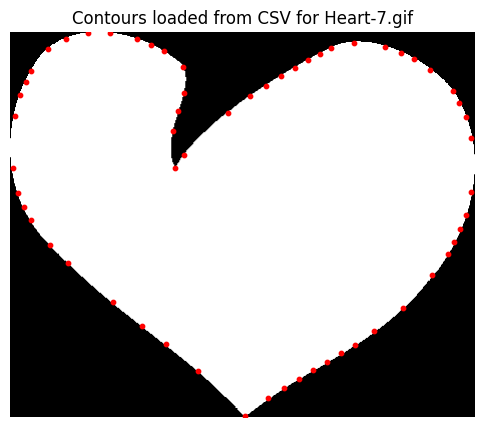

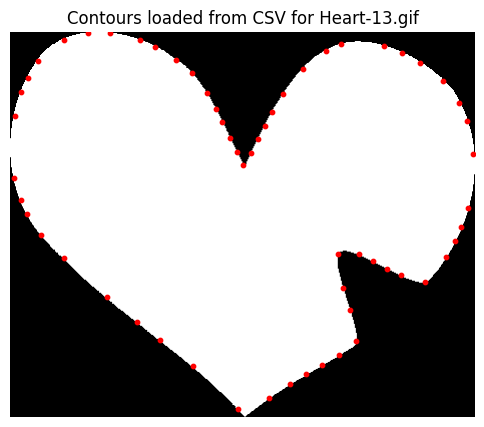

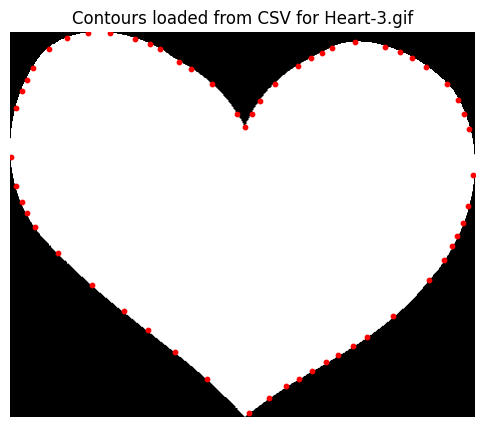

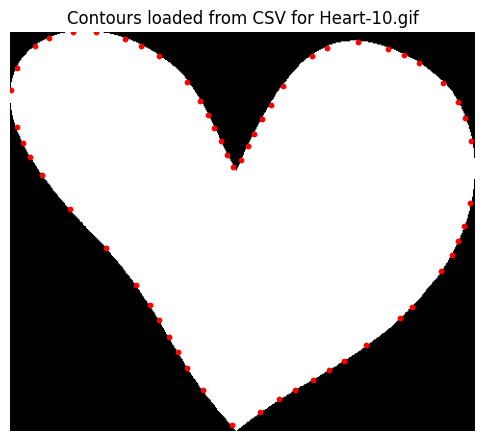

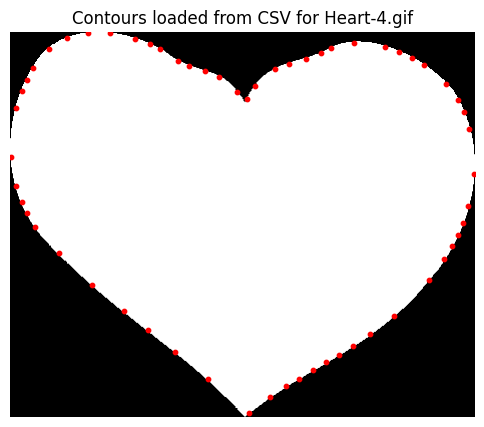

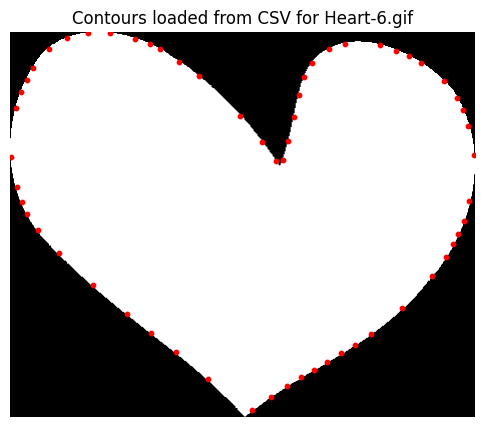

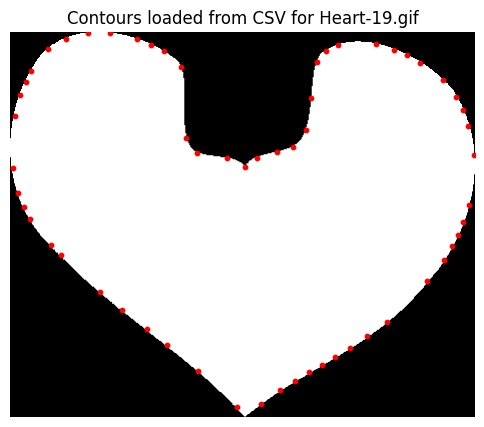

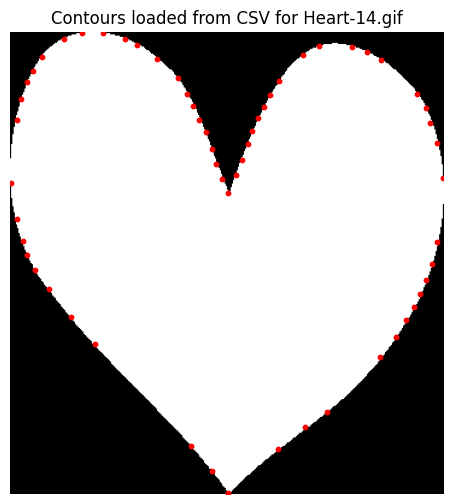

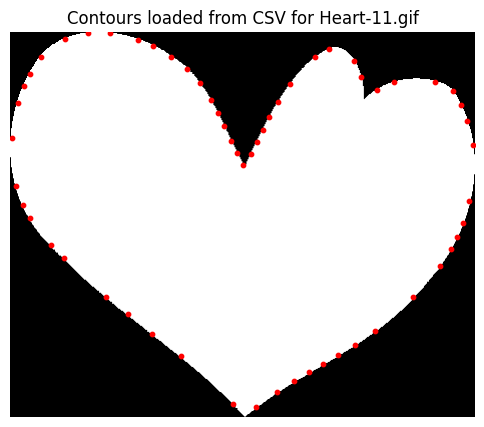

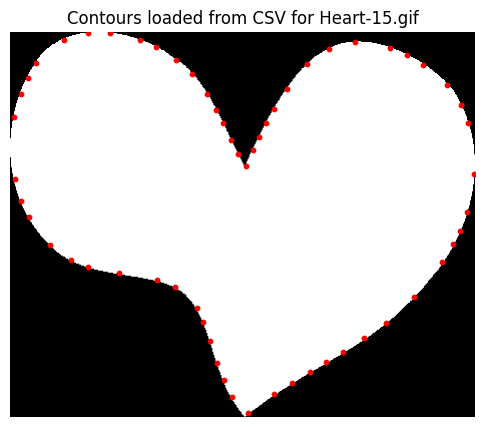

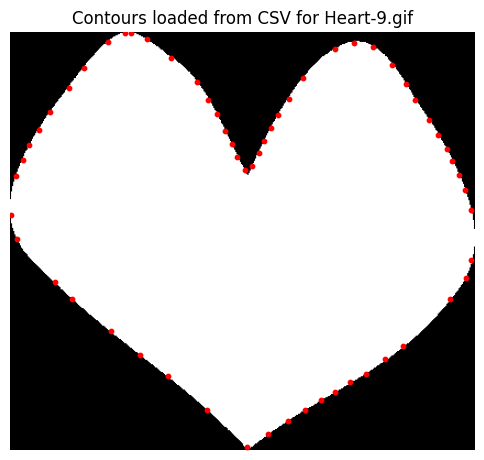

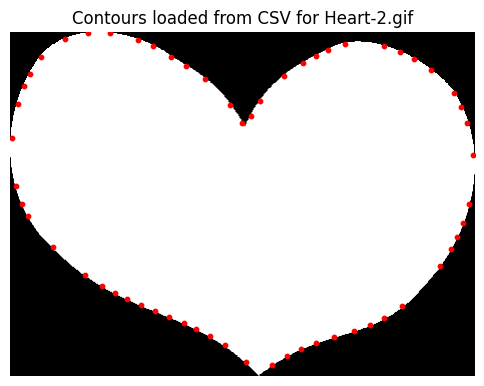

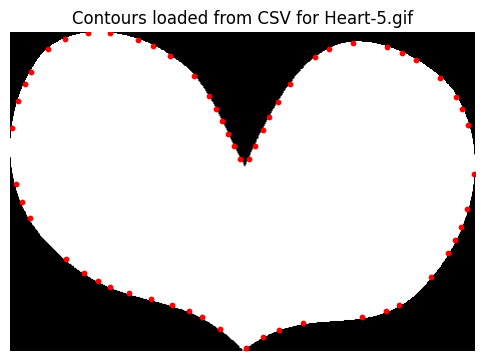

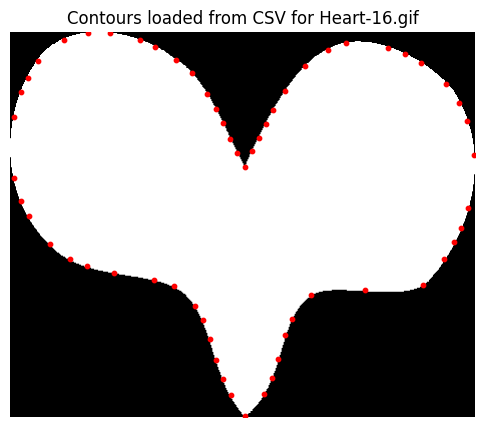

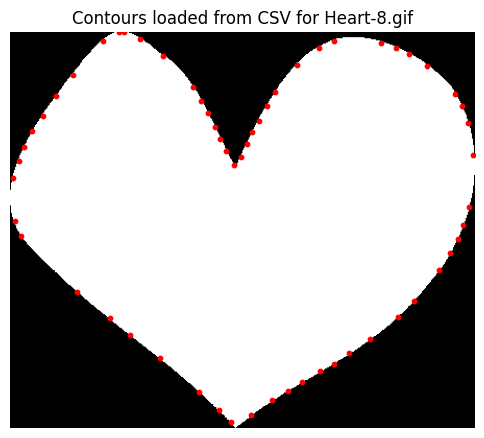

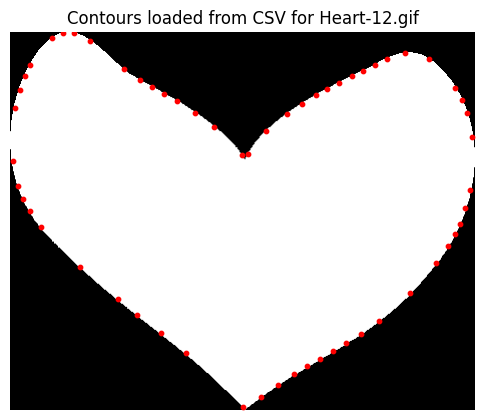


Visualizing contours for class C2_Arbre:


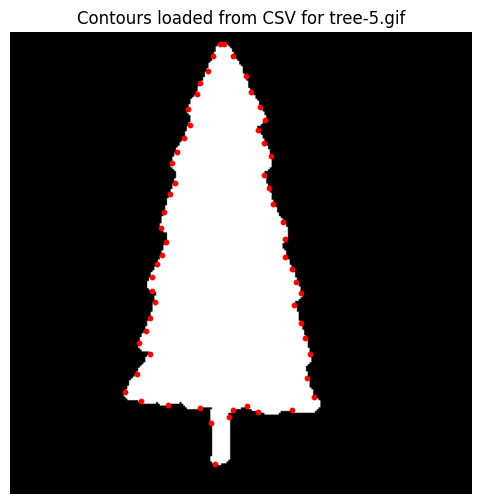

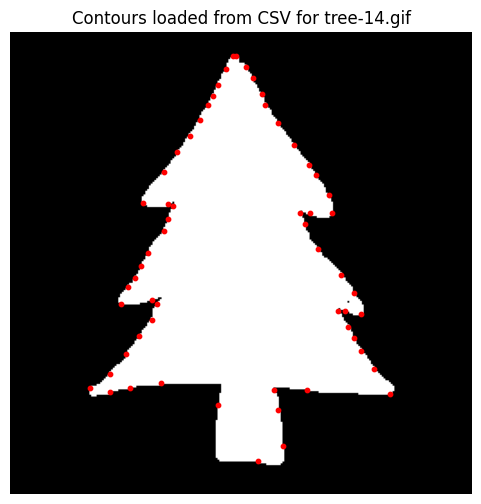

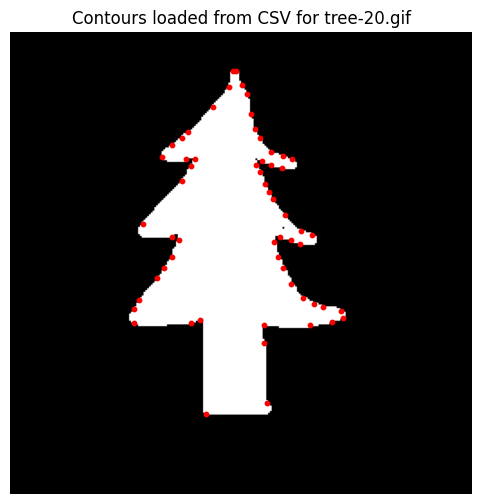

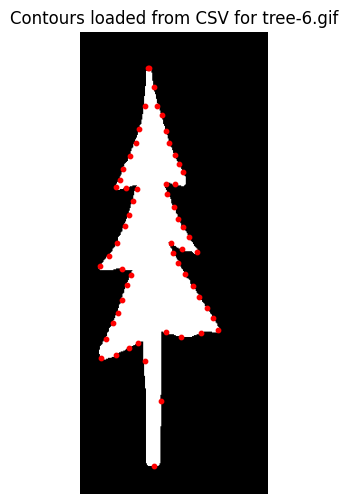

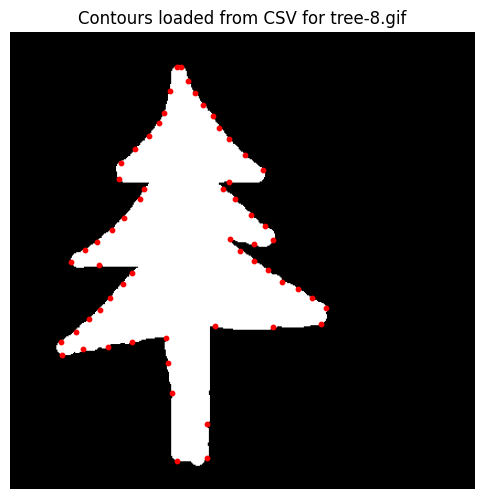

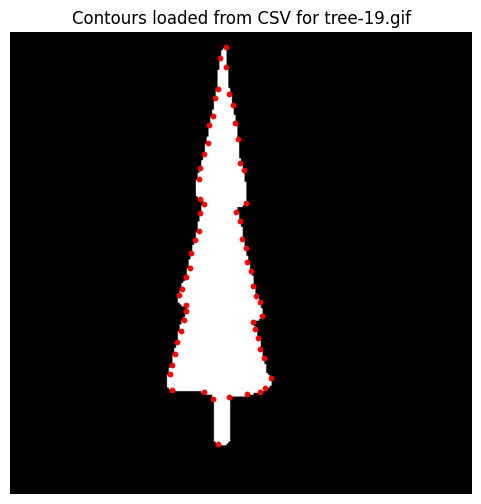

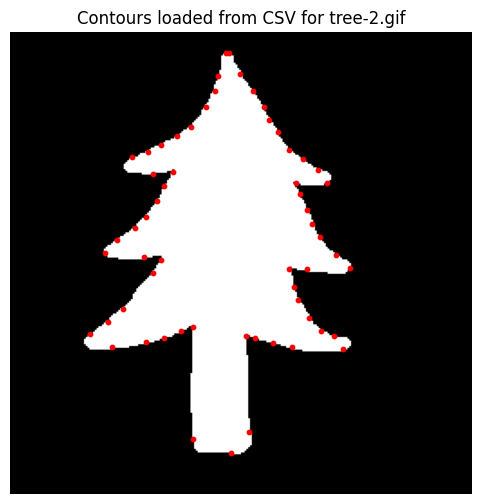

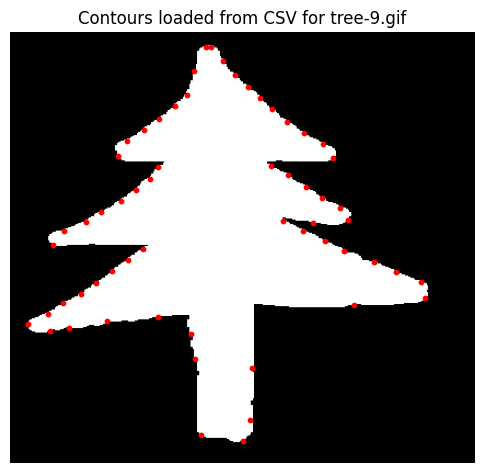

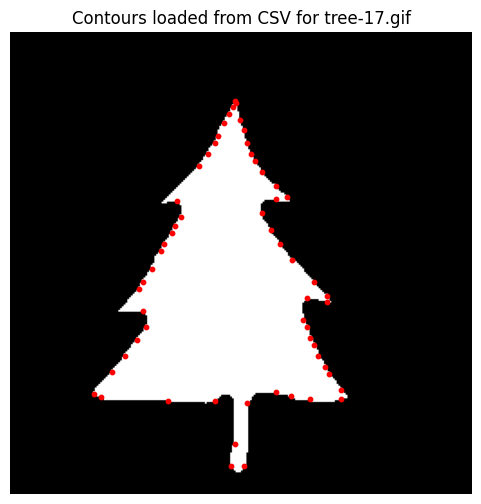

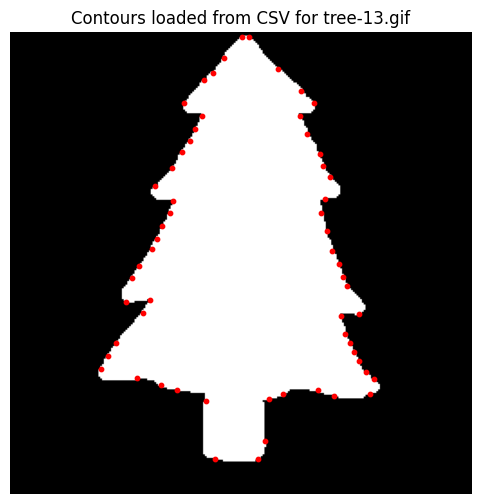

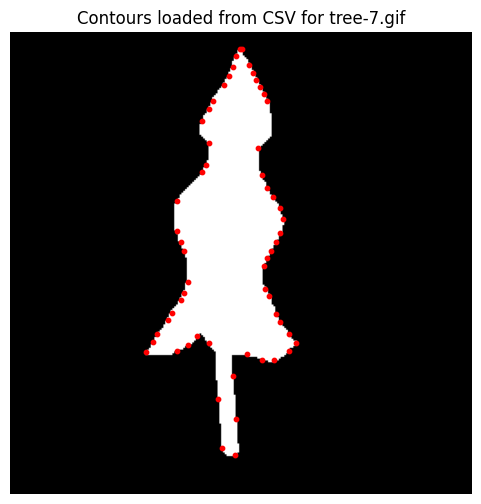

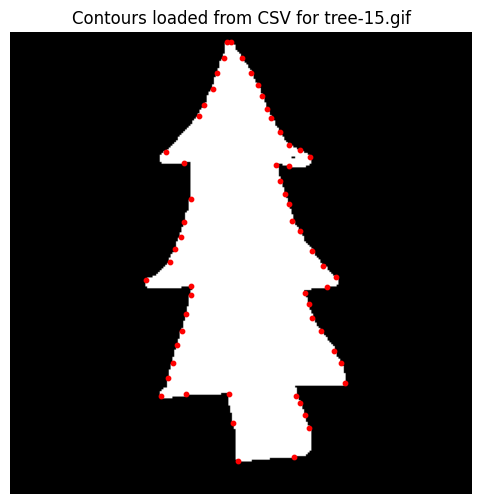

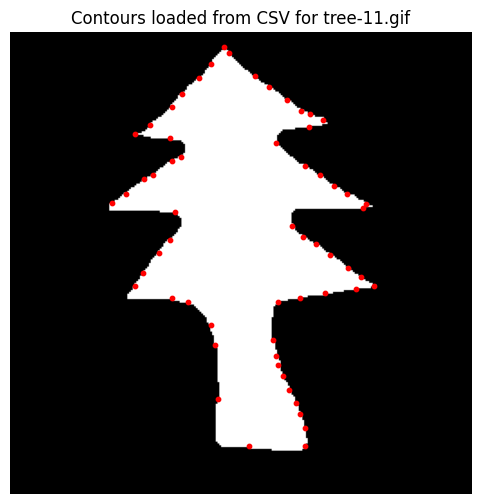

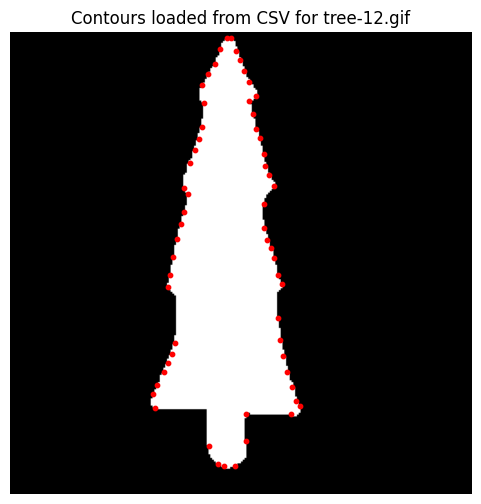

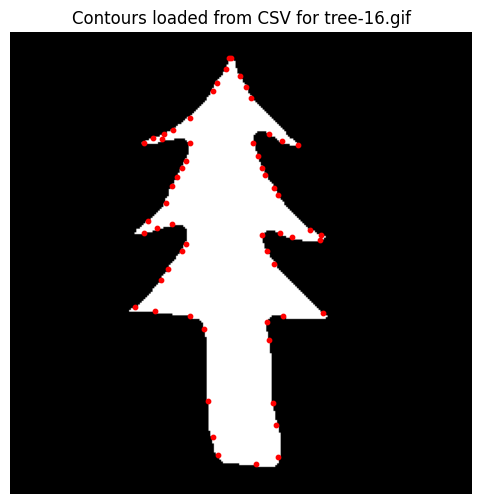

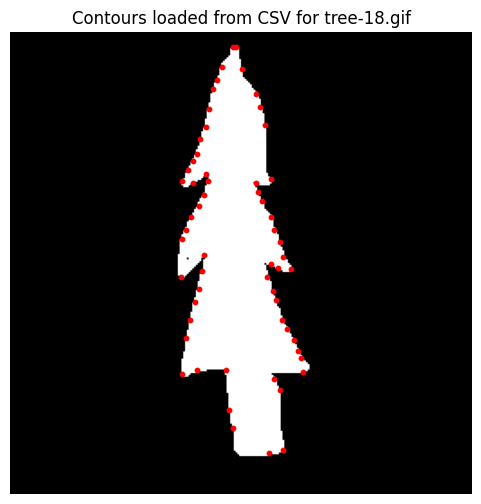


Visualizing contours for class C3_Ours:


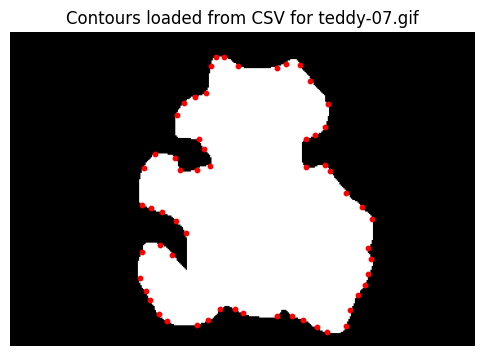

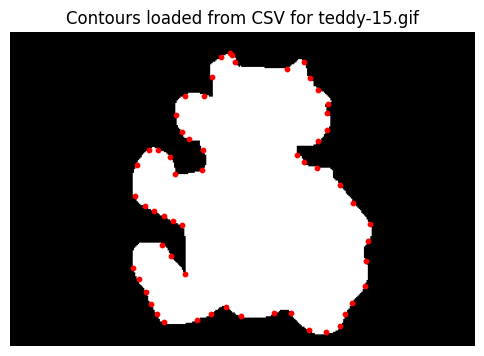

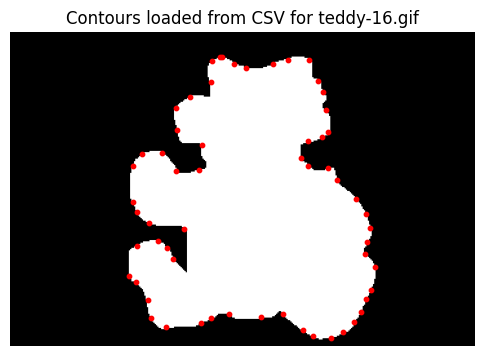

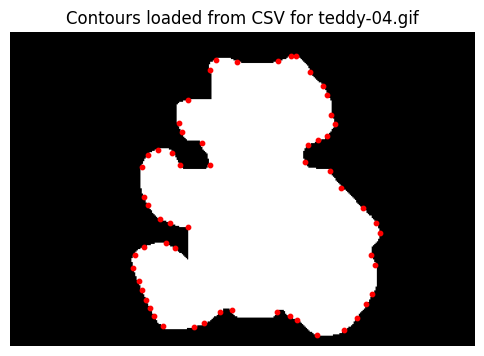

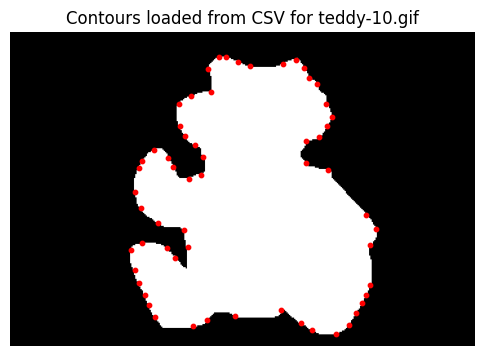

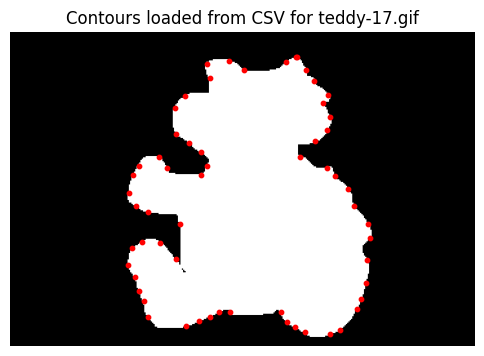

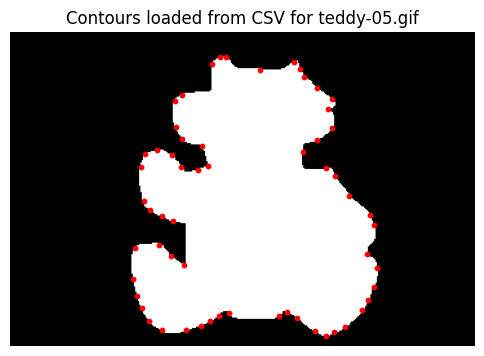

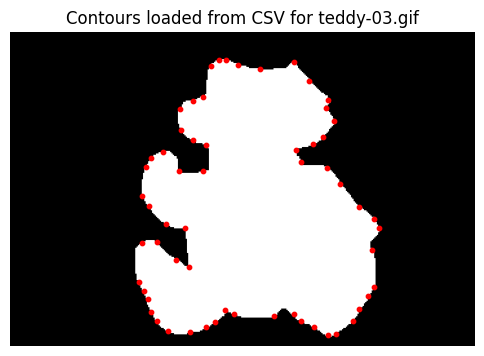

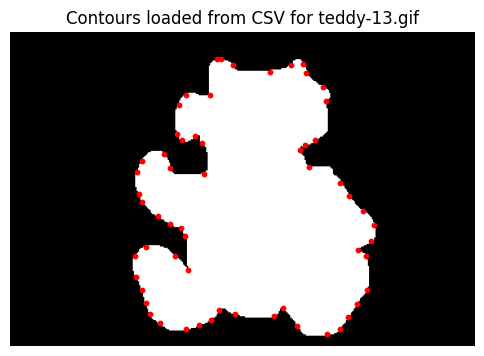

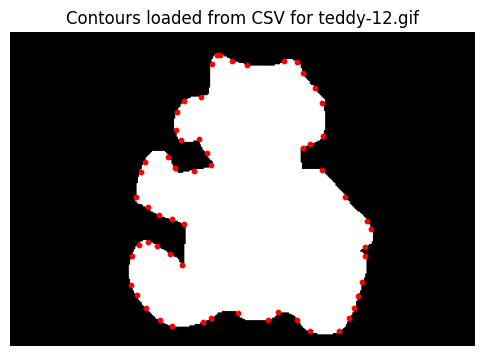

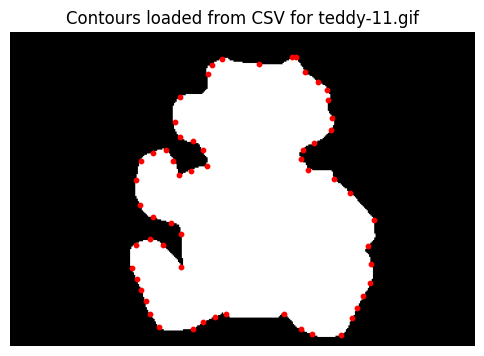

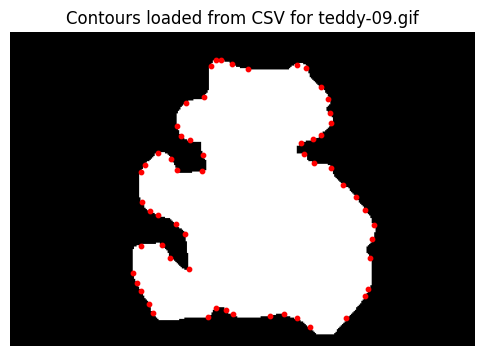

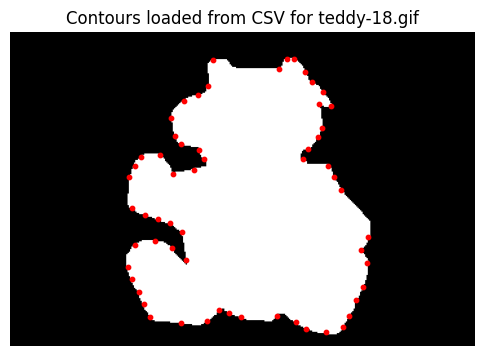

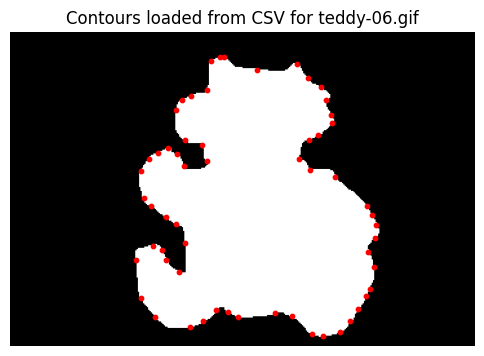

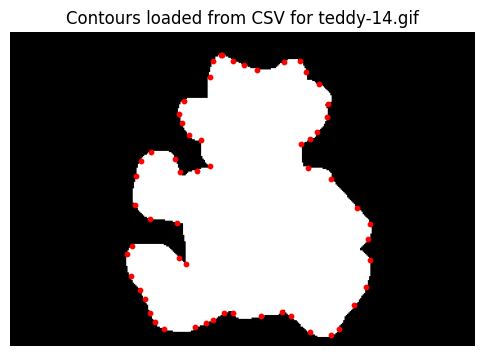

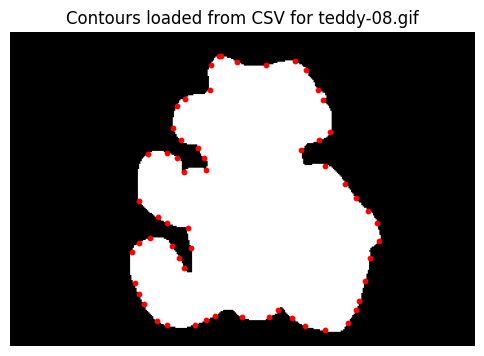


Visualizing contours for class C4_Voiture:


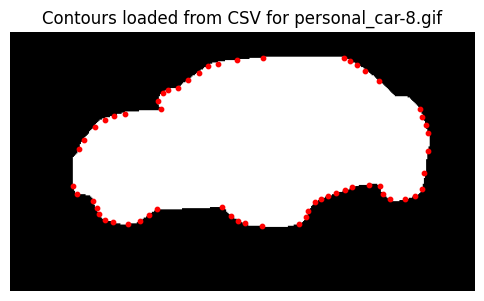

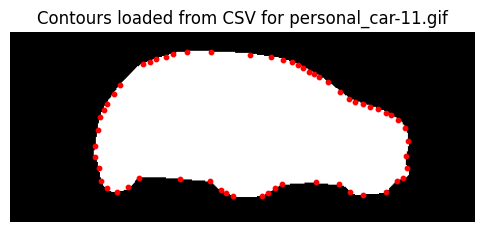

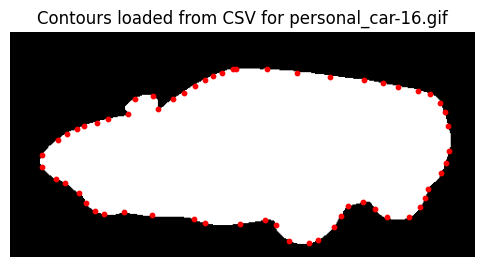

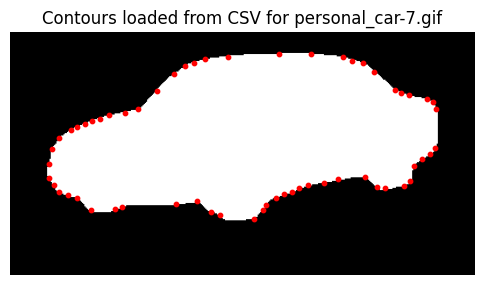

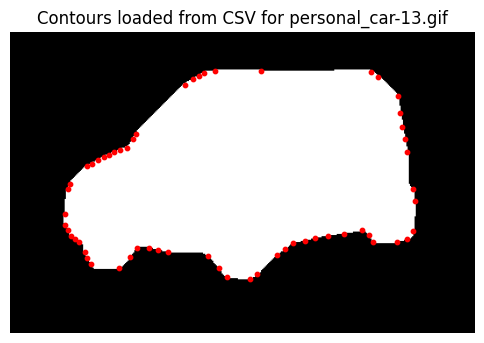

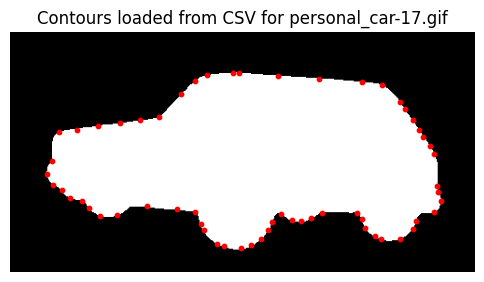

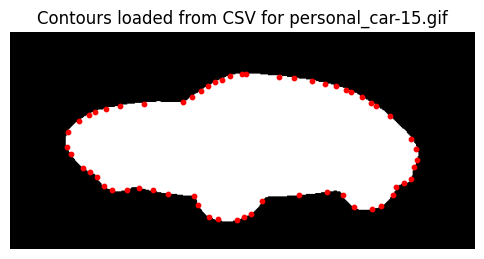

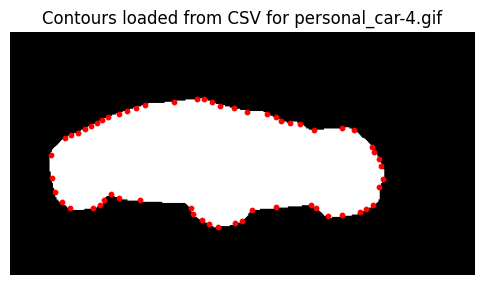

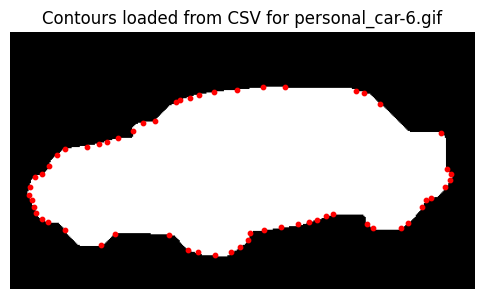

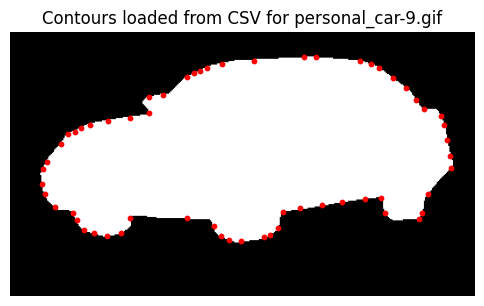

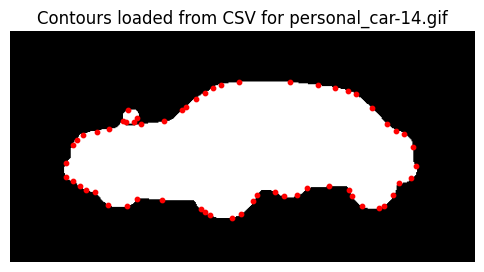

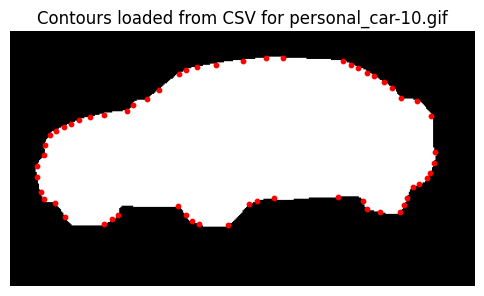

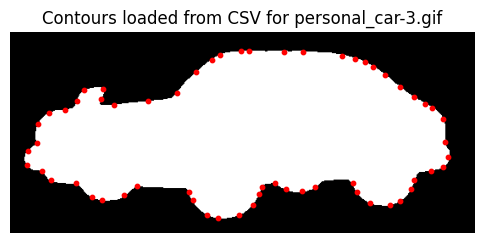

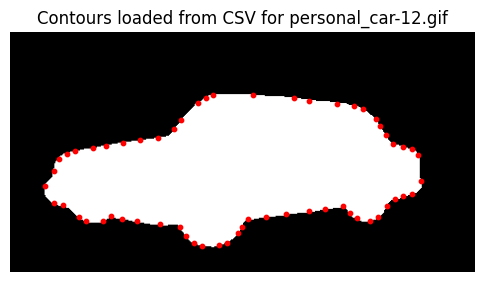

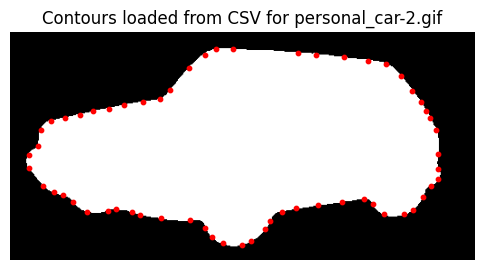

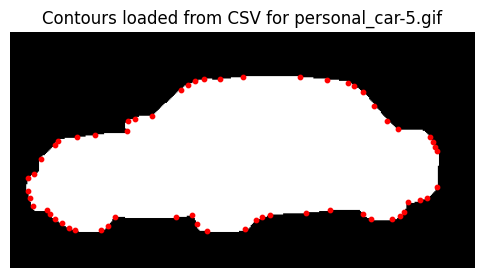


Visualizing contours for class C5_Marteau:


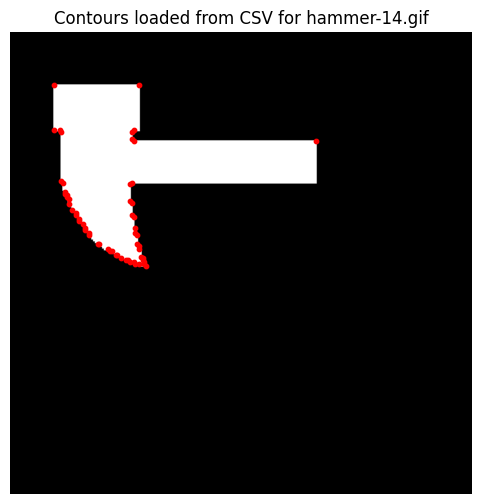

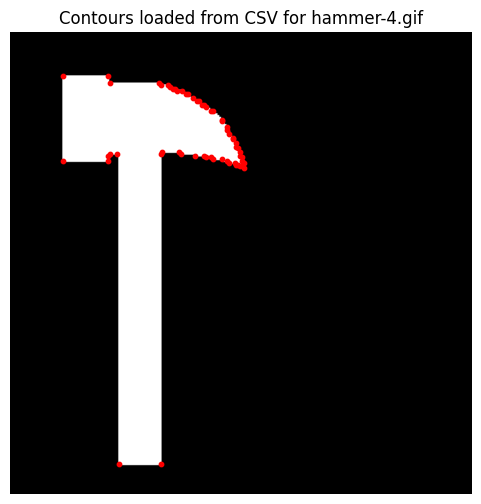

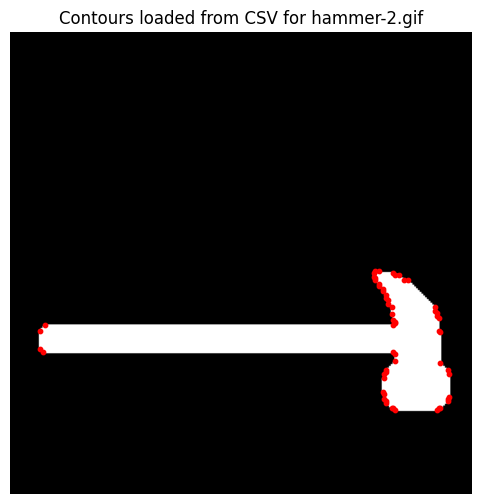

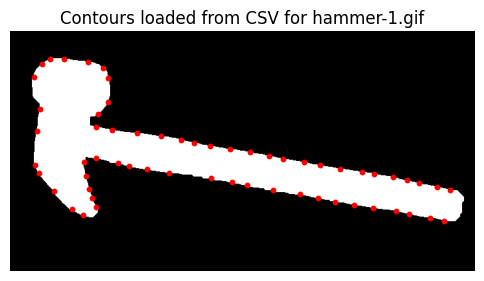

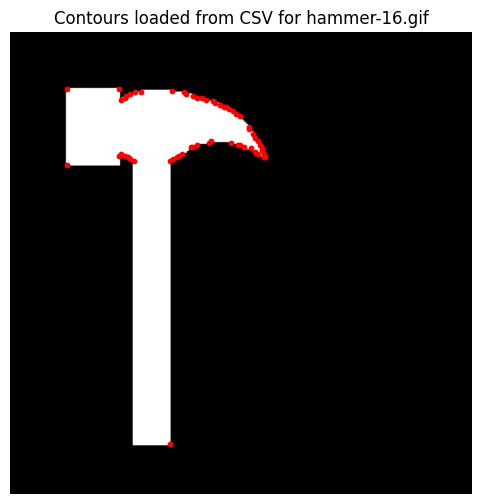

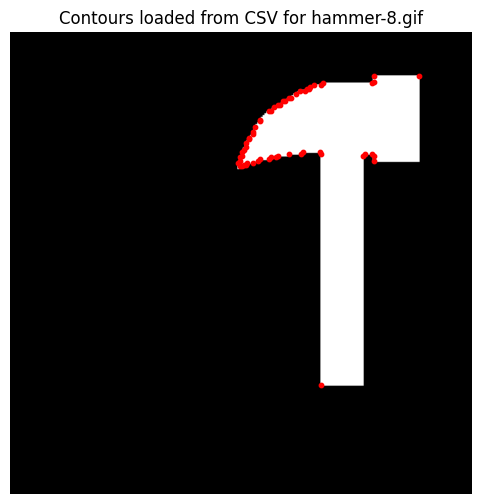

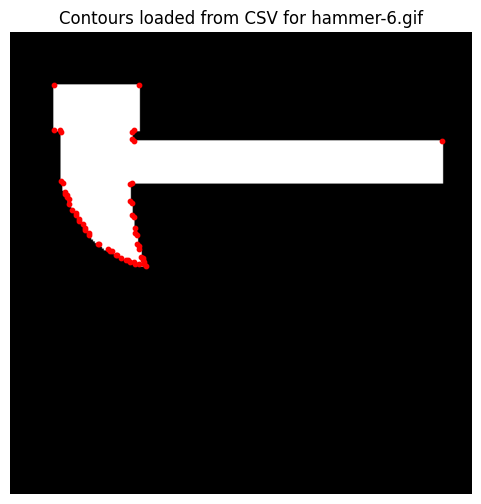

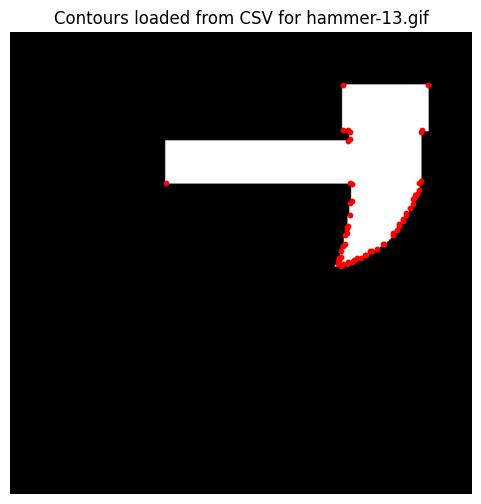

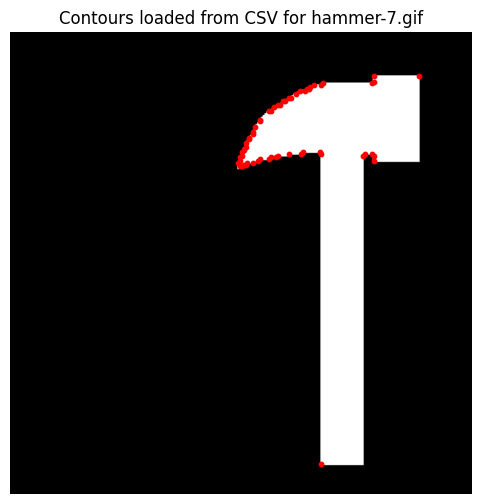

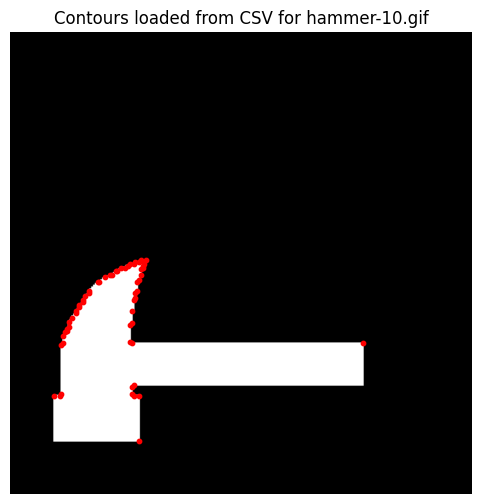

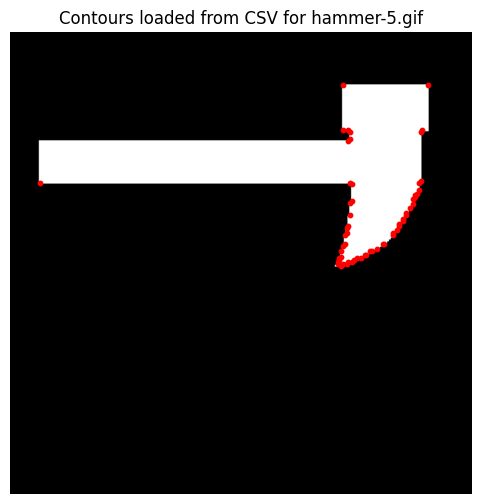

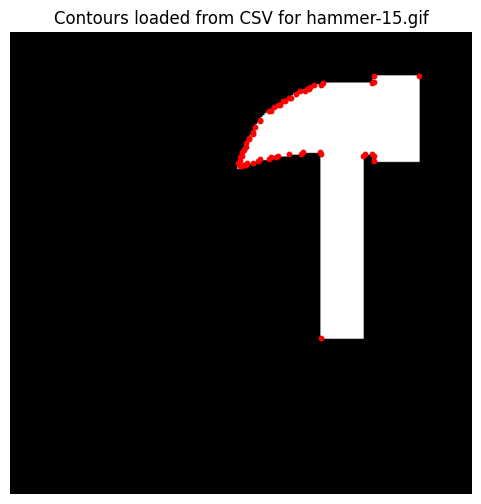

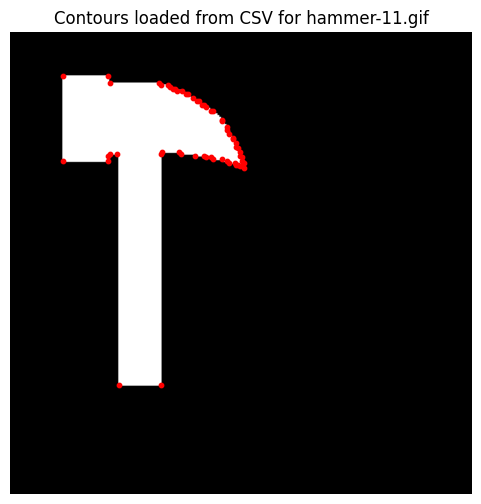

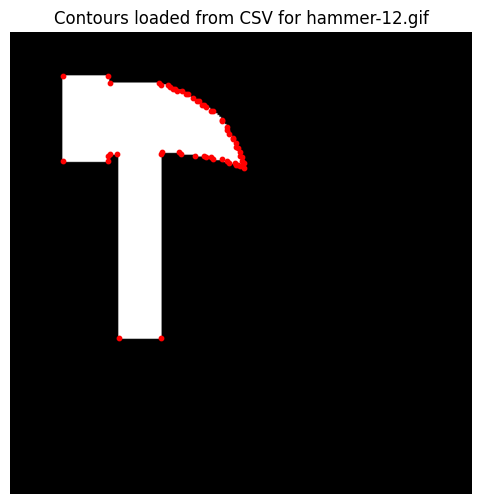

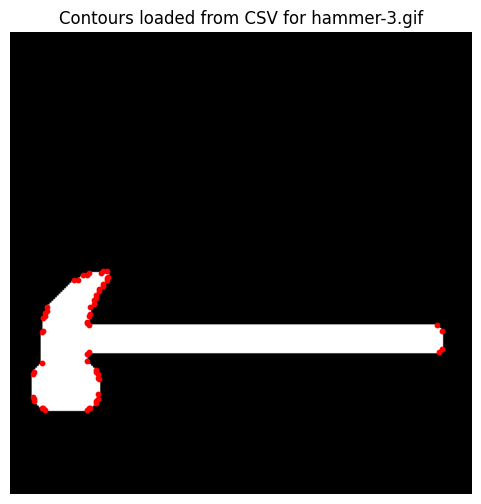

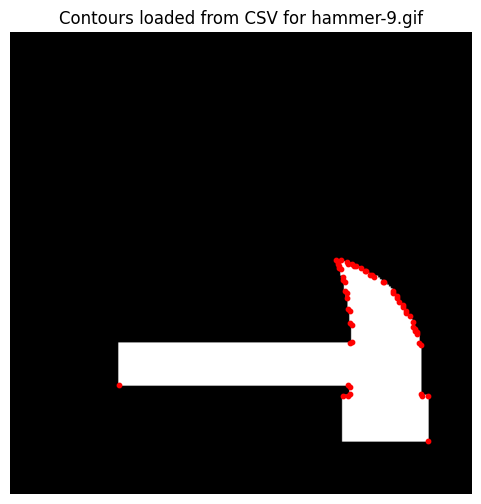

In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# Function to load a binary GIF image
def charger_image_gif_binaire(chemin_image):
    """
    Loads a GIF image, converts it to grayscale, and applies a binary threshold.
    """
    try:
        with Image.open(chemin_image) as img:
            img_gray = img.convert("L")  # Convert to grayscale
            image_np = np.array(img_gray)  # Convert to NumPy array
            binary_image = np.where(image_np > 127, 255, 0).astype(np.uint8)  # Binary threshold
            return binary_image
    except FileNotFoundError:
        print(f"Image not found at path: {chemin_image}")
        return None

# Function to display the image with preloaded contour points
def afficher_image_avec_points(image_path, points_x, points_y):
    """
    Displays the original image with preloaded contour points overlaid.
    """
    image = charger_image_gif_binaire(image_path)
    if image is not None:
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.scatter(points_x, points_y, color='red', s=10, marker='o')
        plt.title(f"Contours loaded from CSV for {os.path.basename(image_path)}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Unable to display image: {image_path}")

# Function to visualize contours from CSV for each class of shapes
def visualiser_points_contours_par_classe(csv_path, images_folder):
    """
    Reads contour points from the CSV file and overlays them on the corresponding images.
    """
    # Load the CSV file with points
    df_points = pd.read_csv(csv_path)

    # Loop over each pair of columns (each image's x and y points)
    for i in range(0, df_points.shape[1], 2):
        col_x_name = df_points.columns[i]
        col_y_name = df_points.columns[i + 1]
        image_name = col_x_name.split("_x")[0] + ".gif"  # Image name with .gif extension

        image_path = os.path.join(images_folder, image_name)

        # Check if the image exists in the directory
        if os.path.exists(image_path):
            points_x = df_points[col_x_name].dropna().values  # x-coordinates of contour points
            points_y = df_points[col_y_name].dropna().values  # y-coordinates of contour points
            afficher_image_avec_points(image_path, points_x, points_y)
        else:
            print(f"Image {image_name} not found in {images_folder}.")

# Dictionary with file paths for each class and corresponding CSV files
class_paths = {
    "C1_Coeur": "/content/Workshop_RF_Data/C1_Coeur_contours.csv",
    "C2_Arbre": "/content/Workshop_RF_Data/C2_Arbre_contours.csv",
    "C3_Ours": "/content/Workshop_RF_Data/C3_Ours_contours.csv",
    "C4_Voiture": "/content/Workshop_RF_Data/C4_Voiture_contours.csv",
    "C5_Marteau": "/content/Workshop_RF_Data/C5_Marteau_contours.csv"
}

# Visualize points for each class
for class_name, csv_path in class_paths.items():
    images_folder = os.path.join("/content/Workshop_RF_Data")
    print(f"\nVisualizing contours for class {class_name}:")
    visualiser_points_contours_par_classe(csv_path, images_folder)


